# AML s26 - Bootstrap 

### Import Libraries

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 

### Load and split data 

In [ ]:
df = pd.read_csv('Auto.csv')
print(df)

X = df[['displacement', 'cylinders', 'weight', 'acceleration']].to_numpy() 

y = df[['mpg']].to_numpy()
print(X, y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

      mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0    18.0          8         307.0         130    3504          12.0    70   
1    15.0          8         350.0         165    3693          11.5    70   
2    18.0          8         318.0         150    3436          11.0    70   
3    16.0          8         304.0         150    3433          12.0    70   
4    17.0          8         302.0         140    3449          10.5    70   
..    ...        ...           ...         ...     ...           ...   ...   
387  27.0          4         140.0          86    2790          15.6    82   
388  44.0          4          97.0          52    2130          24.6    82   
389  32.0          4         135.0          84    2295          11.6    82   
390  28.0          4         120.0          79    2625          18.6    82   
391  31.0          4         119.0          82    2720          19.4    82   

     origin                       name  
0         1  chevrolet

### Set up bootstrap 

In [ ]:
n_iterations = 10000
R2_scores = []

# Bootstrap loop
print("-"*20)
for i in range(n_iterations):
    # Resample with replacement from the training data
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot, y_boot = X_train[indices], y_train[indices]

    # Train a model on the bootstrapped sample
    model = LinearRegression()
    model.fit(X_boot, y_boot)

    # Evaluate on the original, untouched test set
  
    R2_train = model.score(X_boot, y_boot)
    R2_test = model.score(X_test, y_test)
    print("R^2 on train:", R2_train, "R^2 on test:", R2_test)

    R2_scores.append(R2_test)

print("-"*20)

--------------------
R^2 on train: 0.7185492053403819 R^2 on test: 0.7028341717967693
R^2 on train: 0.6905626511382525 R^2 on test: 0.7032696678626166
R^2 on train: 0.6988670842749175 R^2 on test: 0.710908538057355
R^2 on train: 0.7784594647087403 R^2 on test: 0.5450566589241035
R^2 on train: 0.7076581819182715 R^2 on test: 0.7022575483430713
R^2 on train: 0.7291018528826487 R^2 on test: 0.6755442768834381
R^2 on train: 0.7404347745808297 R^2 on test: 0.6190210403696044
R^2 on train: 0.7148710608889004 R^2 on test: 0.7133110698890399
R^2 on train: 0.6925135494626526 R^2 on test: 0.642900353645274
R^2 on train: 0.713631131687672 R^2 on test: 0.7116069265464786
R^2 on train: 0.685125675869626 R^2 on test: 0.6967598000602908
R^2 on train: 0.6851440984193551 R^2 on test: 0.7084055526974642
R^2 on train: 0.7052833401910157 R^2 on test: 0.644775693347126
R^2 on train: 0.6975523127799852 R^2 on test: 0.711282106741024
R^2 on train: 0.759567257598283 R^2 on test: 0.6383514124505028
R^2 on trai

### Analyze results 

In [23]:
average = np.mean(R2_scores)

print(f"R^2 average: {average:.3f}    SE estimate: {np.std(R2_scores):.3f}")


R^2 average: 0.682    SE estimate: 0.037


                 R2
count  10000.000000
mean       0.682397
std        0.036903
min        0.465703
25%        0.658873
50%        0.684114
75%        0.708302
max        0.797806


Text(0.5, 0, 'R^2 Score')

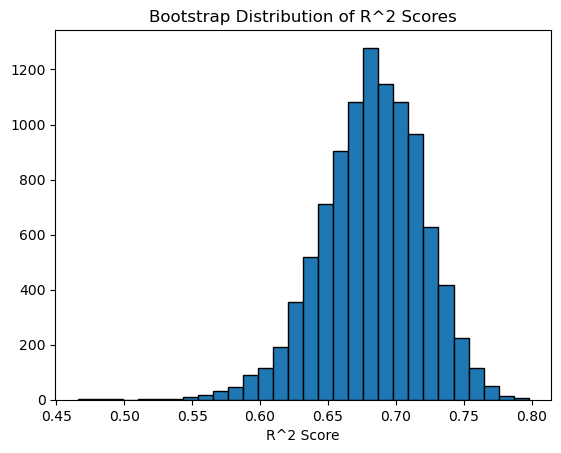

In [24]:
df = pd.DataFrame(R2_scores, columns=['R2'])
print(df.describe())

import matplotlib.pyplot as plt
plt.title('Bootstrap Distribution of R^2 Scores')
plt.hist(R2_scores, bins=30, edgecolor='k')
plt.xlabel('R^2 Score')